# Lab 3 — Descriptive Statistics Assignment: Gym Membership Dataset

**School of Computer Science and Engineering (SOCSE) — RV University**

**Name:** **Bharat Madiwalar**  **Roll No.:** **1RUA25CSE0114**  **Section:** **G**

---

## Instructions

- This is a follow-up to Lab 3 (descriptive statistics on the student survey dataset). The same
  concepts — central tendency, dispersion, distribution shape, and visualization — are applied here
  to a **new dataset** describing gym members, so you can practice choosing the right
  statistic rather than remembering the answer from Lab 3.
-
- Every question below has an empty code cell (marked `# TODO`) for your solution, and most also   have a markdown cell marked **Your answer:** for a short written interpretation. Write your
  interpretation in your own words — a correct number with no explanation will not receive full  marks for questions that ask you to interpret.
- Run your notebook **top to bottom** (Kernel → Restart & Run All) before submitting, and make sure
  it completes with no errors.
-

### Learning objectives
By the end of this assignment you should be able to: compute and correctly choose between mean,
median, and mode; compute and interpret variance, standard deviation, and IQR; use skewness and
kurtosis to identify non-normal distributions; and build/interpret histograms, box plots, and scatter plots to support (or challenge) what the summary statistics suggest.

In [1]:
%pip install pandas


Note: you may need to restart the kernel to use updated packages.


In [2]:
# --- Core libraries used throughout the notebook (provided — no changes needed) ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

RANDOM_SEED = 7
np.random.seed(RANDOM_SEED)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.precision", 3)

print("Libraries loaded. Random seed set to", RANDOM_SEED)

Libraries loaded. Random seed set to 7


In [3]:
df = pd.read_csv("gym_members_synthetic.csv")

FEATURES = [
    "workout_duration_minutes",
    "monthly_membership_fee_inr",
    "attendance_percentage",
    "weekly_visit_count"
]

df.head(8)

,member_id,workout_duration_minutes,monthly_membership_fee_inr,attendance_percentage,weekly_visit_count,preferred_workout
0,M001,69.7,1690.0,71.7,1.3,Cardio
1,M002,81.0,2450.0,86.2,2.2,Weights
2,M003,62.6,2190.0,89.0,5.1,CrossFit
3,M004,65.7,3170.0,79.6,5.4,Cardio
4,M005,49.3,1050.0,80.7,1.5,Weights
5,M006,39.1,1180.0,88.0,5.0,Weights
6,M007,52.3,800.0,81.3,2.1,Weights
7,M008,73.0,2630.0,82.3,5.5,Yoga


## Part 1 — The Dataset (provided, do not modify)

This dataset simulates **150 gym members**, with the same design idea as Lab 3: each numeric
feature is deliberately shaped differently, so no single statistic works well for all of them.

| Feature | Real-world meaning | Intended shape |
|---|---|---|
| `workout_duration_minutes` | Average length of a workout session | *(shape not disclosed — see Q7/Q8)* |
| `monthly_membership_fee_inr` | Monthly membership fee paid (₹) | *(shape not disclosed — see Q7/Q8)* |
| `attendance_percentage` | % of scheduled sessions actually attended | *(shape not disclosed — see Q7/Q8)* |
| `weekly_visit_count` | Number of gym visits per week | *(shape not disclosed — see Q7/Q8)* |
| `preferred_workout` | Favorite workout category | categorical |

Unlike Lab 3, the shapes are **not labeled** for you this time — figuring out which feature is
approximately normal, right-skewed, left-skewed, or bimodal (and *proving it* with statistics and
plots) is part of the assignment.

In [4]:
df=pd.read_csv("gym_members_synthetic.csv")
df.head(8)

,member_id,workout_duration_minutes,monthly_membership_fee_inr,attendance_percentage,weekly_visit_count,preferred_workout
0,M001,69.7,1690.0,71.7,1.3,Cardio
1,M002,81.0,2450.0,86.2,2.2,Weights
2,M003,62.6,2190.0,89.0,5.1,CrossFit
3,M004,65.7,3170.0,79.6,5.4,Cardio
4,M005,49.3,1050.0,80.7,1.5,Weights
5,M006,39.1,1180.0,88.0,5.0,Weights
6,M007,52.3,800.0,81.3,2.1,Weights
7,M008,73.0,2630.0,82.3,5.5,Yoga


### Q1 (2 marks) — Initial exploration

In the code cell below: display the shape of `df`, the data type of each column (`.dtypes`), the
summary statistics of the numeric columns (`.describe()`), and check whether any values are
missing (`.isna().sum()`).

In [5]:
# TODO: Q1 — shape, dtypes, describe(), and missing-value check

print("Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nSummary Statistics:")
print(df[FEATURES].describe())

print("\nMissing Values:")
print(df.isna().sum())

Shape: (150, 6)

Data Types:
member_id                         str
workout_duration_minutes      float64
monthly_membership_fee_inr    float64
attendance_percentage         float64
weekly_visit_count            float64
preferred_workout                 str
dtype: object

Summary Statistics:
       workout_duration_minutes  monthly_membership_fee_inr  \
count                   150.000                     150.000   
mean                     54.618                    2283.067   
std                      11.397                     984.837   
min                      27.800                     800.000   
25%                      48.050                    1515.000   
50%                      54.350                    2030.000   
75%                      62.875                    2825.000   
max                      81.000                    6420.000   

       attendance_percentage  weekly_visit_count  
count                150.000             150.000  
mean                  84.210          

## Part 2 — Measures of Central Tendency

Recall from Lab 3: the **mean** uses every value and is efficient but outlier-sensitive; the
**median** only depends on the middle position and is robust to outliers; the **mode** is the most
frequent value and is most meaningful for categorical or discrete data.



In the code cell below, compute the **mean, median, and mode** of each of the four numeric features
in `FEATURES`, and separately the **mode** of `preferred_workout`. Present the four numeric results
as a single small table (a DataFrame is fine).

In [6]:
# TODO: Q2 — mean, median, mode for each numeric feature; mode of preferred_workout

# Q2 — mean, median, mode for each numeric feature

results = []

for feature in FEATURES:
    results.append({
        "Feature": feature,
        "Mean": df[feature].mean(),
        "Median": df[feature].median(),
        "Mode": df[feature].mode().iloc[0]
    })

central_tendency = pd.DataFrame(results)
print(central_tendency)

print("\nMode of preferred_workout:")
print(df["preferred_workout"].mode().tolist())

                      Feature      Mean   Median    Mode
0    workout_duration_minutes    54.618    54.35    57.8
1  monthly_membership_fee_inr  2283.067  2030.00  1440.0
2       attendance_percentage    84.210    85.10    85.1
3          weekly_visit_count     3.337     2.40     2.3

Mode of preferred_workout:
['Cardio', 'Weights']


### Q3  — Written interpretation

Looking at your table from Q2: for which numeric feature(s) do the mean and median differ the most
(in relative, not absolute, terms)? What does that gap suggest about the shape of that feature's
distribution, and in which direction would you expect its tail to stretch? You have not plotted
anything yet — base your answer only on the numbers.

**Your answer:**

The monthly membership fee has the largest relative difference between its mean and median. Its mean is about ₹2283 while the median is ₹2030, suggesting that the distribution is right-skewed. This means there are some relatively high membership fees creating a longer tail toward the right.


### Q4 (4 marks) — The outlier effect

Suppose one gym member signs up for a **founder's lifetime membership** and pays a one-time fee of
**₹80,000** that month. In the code cell below: make a **copy** of `df` (do not modify the original
`df`), add this one hypothetical value to `monthly_membership_fee_inr` in the copy, and print the
mean and median of that column **before and after** adding it.

Then, in the markdown cell below, explain in 2–3 sentences why the mean and median reacted
differently, referencing what you know about how each statistic is calculated.

In [7]:
# TODO: Q4 — add the ₹80,000 outlier to a COPY of df, compare mean/median before vs. after



df_outlier = df.copy()

before_mean = df_outlier["monthly_membership_fee_inr"].mean()
before_median = df_outlier["monthly_membership_fee_inr"].median()

# Add hypothetical founder's lifetime membership
df_outlier.loc[len(df_outlier), "monthly_membership_fee_inr"] = 80000

after_mean = df_outlier["monthly_membership_fee_inr"].mean()
after_median = df_outlier["monthly_membership_fee_inr"].median()

print("Before adding outlier:")
print("Mean:", before_mean)
print("Median:", before_median)

print("\nAfter adding ₹80,000 outlier:")
print("Mean:", after_mean)
print("Median:", after_median)

Before adding outlier:
Mean: 2283.0666666666666
Median: 2030.0

After adding ₹80,000 outlier:
Mean: 2797.748344370861
Median: 2030.0


**Your answer:**

Before adding the outlier, the mean membership fee is about ₹2283.07 and the median is ₹2030. After adding the ₹80,000 fee, the mean increases substantially to about ₹2797.75, while the median remains ₹2030. The mean changes more because it uses every value and is strongly affected by an extreme value, whereas the median depends mainly on the middle position of the sorted data.


## Part 3 — Measures of Dispersion

### Q5 (5 marks) — Manual calculation

Without using `.var()`, `.std()`, `np.var()`, or `np.std()`, calculate the **variance** and
**standard deviation** of `workout_duration_minutes` by hand, following the sample-variance formula:

$$
\text{variance} = \frac{\sum_{i=1}^{n}(x_i - \bar{x})^2}{n-1}
\qquad\qquad
\text{standard deviation} = \sqrt{\text{variance}}
$$

Work through it step by step (compute the mean, then the deviations, then the squared deviations,
then the variance, then the standard deviation — printing each intermediate result), and then
verify your manual answer matches `np.var(..., ddof=1)` and `np.std(..., ddof=1)`.

In [8]:
# TODO: Q5 — manual variance & standard deviation for workout_duration_minutes, then verify

# Q5 — Manual variance & standard deviation

x = df["workout_duration_minutes"].values
n = len(x)


mean_x = sum(x) / n
print("Mean:", mean_x)

deviations = x - mean_x
print("\nDeviations:")
print(deviations)

squared_deviations = deviations ** 2
print("\nSquared deviations:")
print(squared_deviations)

sum_squared_deviations = sum(squared_deviations)
print("\nSum of squared deviations:", sum_squared_deviations)

variance = sum_squared_deviations / (n - 1)
print("\nManual sample variance:", variance)

std_dev = np.sqrt(variance)
print("Manual standard deviation:", std_dev)

print("\nVerification:")
print("np.var:", np.var(x, ddof=1))
print("np.std:", np.std(x, ddof=1))

Mean: 54.618

Deviations:
[ 15.082  26.382   7.982  11.082  -5.318 -15.518  -2.318  18.382 -21.918
  -5.518 -22.618   1.682  10.882 -14.518  -4.518  16.282  -0.718 -14.518
 -15.418 -23.818   9.682  -8.618  12.982  10.782  -7.518  -5.918   9.682
   2.182   3.582 -19.418  11.182 -10.118 -26.818  -7.018   5.482  25.582
  -4.118 -15.618  25.882   2.282  -2.718 -12.518 -11.618  18.082  -2.818
  -6.118  -5.718  19.182  -6.718   7.882   3.582   3.282 -10.118   8.282
  19.682  -0.218 -10.618 -15.118   2.682  -2.918  -0.918   0.482 -17.318
   9.782   3.182  -0.518   3.182  11.482   0.982  -9.818  14.382  -4.818
  -8.318 -18.318   0.482 -12.218  -5.818   5.782   0.782  12.582   4.082
  -4.418  -3.618  -5.718   8.182   0.682  -4.518  10.482   1.582  -5.218
 -17.718   5.582   3.282   0.982  -4.818  -9.618  -2.318   3.182  -1.118
  -1.318  -5.218   4.482   3.182  -8.618   9.482   9.882  10.182  -1.218
  -1.918 -13.518   9.482 -25.218  -4.318  -3.718  10.682   0.382 -11.218
 -16.718  -8.318   1.682 

### Q6 — IQR and outlier detection

For **each** of the four numeric features: compute Q1, Q3, and the IQR; compute the lower bound
(`Q1 - 1.5*IQR`) and upper bound (`Q3 + 1.5*IQR`); and count how many values fall outside those
bounds (i.e., how many outliers each feature has by this rule).

**Your answer (2–3 sentences):** Which feature has the most outliers by this rule? Suggest one
real-world reason a gym dataset might realistically show that pattern for that feature.

**Monthly membership fee has the most outliers, with two values outside the 1.5 × IQR bounds. A realistic reason is that gyms can have premium plans, special packages, or unusually expensive memberships that are much higher than the standard monthly fee.
**

In [9]:
# TODO: Q6 — Q1, Q3, IQR, bounds, and outlier count for each of the four numeric features

iqr_results = []

for feature in FEATURES:
    q1 = df[feature].quantile(0.25)
    q3 = df[feature].quantile(0.75)
    iqr = q3 - q1
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outliers = df[
        (df[feature] < lower_bound) |
        (df[feature] > upper_bound)
    ]
    
    iqr_results.append({
        "Feature": feature,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": len(outliers)
    })

iqr_table = pd.DataFrame(iqr_results)
print(iqr_table)

                      Feature        Q1        Q3       IQR  Lower Bound  \
0    workout_duration_minutes    48.050    62.875    14.825       25.812   
1  monthly_membership_fee_inr  1515.000  2825.000  1310.000     -450.000   
2       attendance_percentage    80.175    88.775     8.600       67.275   
3          weekly_visit_count     1.800     5.300     3.500       -3.450   

   Upper Bound  Outlier Count  
0       85.113              0  
1     4790.000              2  
2      101.675              1  
3       10.550              0  


## Part 4 — Measures of Distribution Shape

### Q7 Compute the **skewness** and **excess kurtosis** of each of the four numeric features (use
`scipy.stats.skew` and `scipy.stats.kurtosis(..., fisher=True)`, or the equivalent pandas
`.skew()` / `.kurt()` methods). Present the results as a table.

For each feature, classify it as **right-skewed**, **left-skewed**, or **approximately symmetric**
based on the skewness value, and note whether the kurtosis suggests heavier tails, lighter tails, or
roughly normal tails compared to a normal distribution.

In [10]:
# TODO: Q7 — skewness & excess kurtosis for each numeric feature, plus your classification


shape_results = []

for feature in FEATURES:
    skewness = stats.skew(df[feature])
    kurtosis = stats.kurtosis(df[feature], fisher=True)
    
    if skewness > 0.5:
        skew_class = "Right-skewed"
    elif skewness < -0.5:
        skew_class = "Left-skewed"
    else:
        skew_class = "Approximately symmetric"
    
    if kurtosis > 0.5:
        kurt_class = "Heavier tails"
    elif kurtosis < -0.5:
        kurt_class = "Lighter tails"
    else:
        kurt_class = "Roughly normal tails"
    
    shape_results.append({
        "Feature": feature,
        "Skewness": skewness,
        "Excess Kurtosis": kurtosis,
        "Skewness Classification": skew_class,
        "Kurtosis Interpretation": kurt_class
    })

shape_table = pd.DataFrame(shape_results)
print(shape_table)

                      Feature  Skewness  Excess Kurtosis  \
0    workout_duration_minutes     0.080           -0.194   
1  monthly_membership_fee_inr     1.165            1.761   
2       attendance_percentage    -0.556           -0.353   
3          weekly_visit_count     0.441           -1.369   

   Skewness Classification Kurtosis Interpretation  
0  Approximately symmetric    Roughly normal tails  
1             Right-skewed           Heavier tails  
2              Left-skewed    Roughly normal tails  
3  Approximately symmetric           Lighter tails  


### Q8 — Predict before you plot

Based only on the real-world meaning of each feature (not the numbers you've computed) — which of
the four features do you predict is **bimodal** (i.e., has two distinct groups of members rather
than one central tendency)? Explain your reasoning in 2–3 sentences, thinking about what kinds of
gym members might behave very differently from each other.

**Your answer:**
**I predict that weekly_visit_count will be bimodal. In a gym, some members may be casual users who visit only a few times per week, while another group may be highly committed members who visit almost every day. These two different groups could create two peaks in the distribution.
**

## Part 5 — Data Visualizations

### Q9  — Histograms

Create a **2×2 grid of histograms** (one per numeric feature) with a KDE (density) curve overlaid
on each. On each subplot, draw a vertical line for the mean and a different-styled vertical line
for the median (with a legend), and give each subplot a clear title.

*Hint: `sns.histplot(..., kde=True, stat="density")` and `ax.axvline(...)` are useful here — see
Lab 3 for a similar example if you get stuck.*

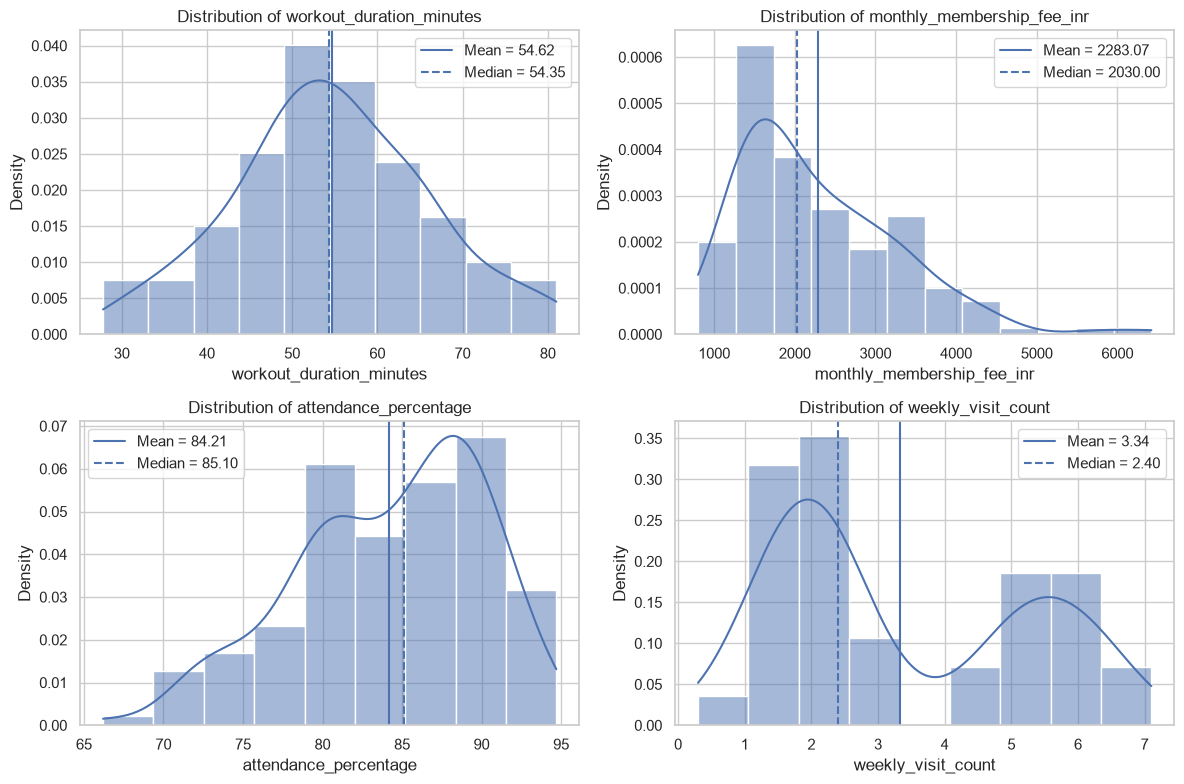

In [11]:
# TODO: Q9 — 2x2 histogram grid with KDE, mean line, and median line per feature

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(FEATURES):
    ax = axes[i]
    
    sns.histplot(
        df[feature],
        kde=True,
        stat="density",
        ax=ax
    )
    
    mean_value = df[feature].mean()
    median_value = df[feature].median()
    
    ax.axvline(
        mean_value,
        linestyle="-",
        label=f"Mean = {mean_value:.2f}"
    )
    
    ax.axvline(
        median_value,
        linestyle="--",
        label=f"Median = {median_value:.2f}"
    )
    
    ax.set_title(f"Distribution of {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Density")
    ax.legend()

plt.tight_layout()
plt.show()

### Q10 

Does the histogram for the feature you predicted in Q8 confirm or contradict your prediction?
If your prediction was wrong, which feature actually turned out to be bimodal, and does the mean
computed in Q2 fall in a sensible place on that histogram, or does it fall in an empty "valley"?

**Your answer:**

The histogram of weekly_visit_count confirms the prediction of a bimodal distribution. There appears to be one group of members who visit around 1–2 times per week and another group who visit around 5–6 times per week. The mean of about 3.34 falls between these groups, close to the valley rather than representing a typical member.


### Q11  — Box plots

Standardize (z-score) the four numeric features — `z = (x - mean) / std` — and plot all four as **box plots side by side** on one figure, so their spreads are visually comparable despite being ondifferent original scales (₹, minutes, %, visits). Label the y-axis clearly. Briefly note in the plot title or a code comment which feature(s) show visible outlier points.

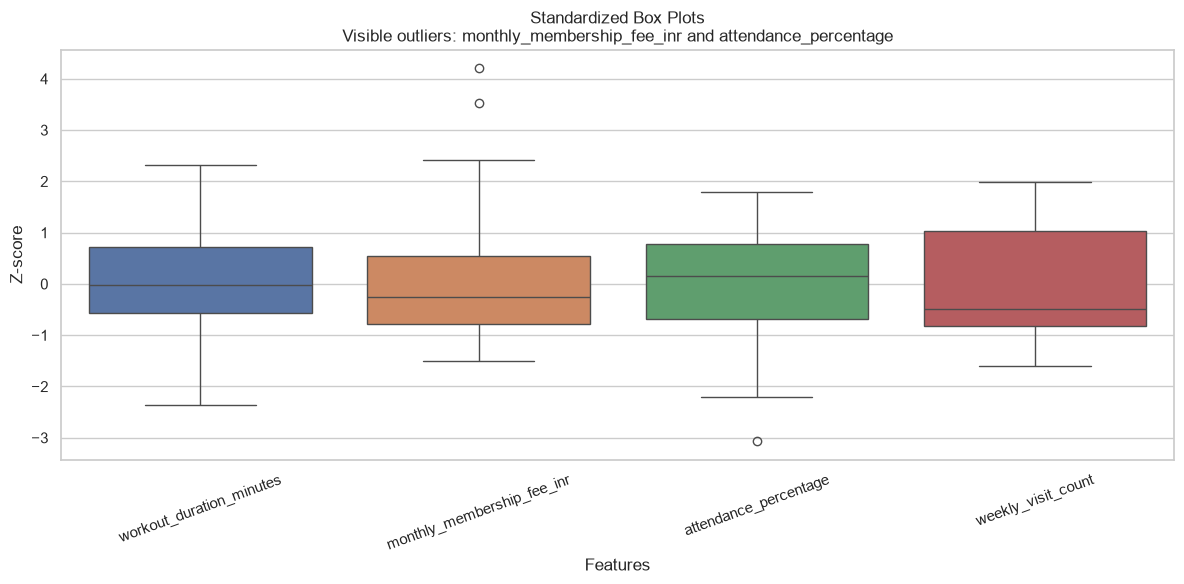

In [12]:
# TODO: Q11 — standardize all four features and plot them as side-by-side box plots

z_df = pd.DataFrame()

for feature in FEATURES:
    z_df[feature] = (
        df[feature] - df[feature].mean()
    ) / df[feature].std()

plt.figure(figsize=(12, 6))

sns.boxplot(data=z_df)

plt.title(
    "Standardized Box Plots\n"
    "Visible outliers: monthly_membership_fee_inr and attendance_percentage"
)

plt.xlabel("Features")
plt.ylabel("Z-score")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Q12 — Scatter plots

Choose **two pairs** of numeric features: one pair you hypothesize has a real relationship, and one
pair you hypothesize has little to no relationship. For each pair: compute the Pearson correlation
coefficient (`.corr()`), make a scatter plot, and put the correlation value in the plot title.

**Your answer (1–2 sentences per pair):** Did the scatter plots and correlation values support your
hypotheses? If a result surprised you, say so.

For attendance_percentage and weekly_visit_count, the correlation is approximately 0.521, showing a moderate positive relationship. The scatter plot supports the hypothesis that members who attend a larger percentage of their scheduled sessions tend to visit the gym more frequently.

For workout_duration_minutes and monthly_membership_fee_inr, the correlation is approximately -0.021, which is essentially no linear relationship. The scatter plot also shows no clear trend, so this pair supports the hypothesis of little to no relationship.


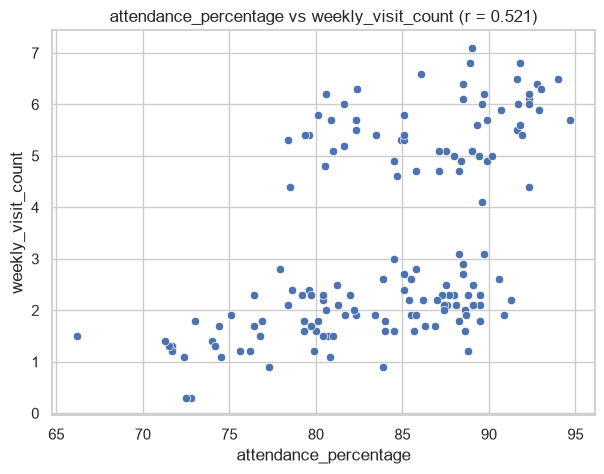

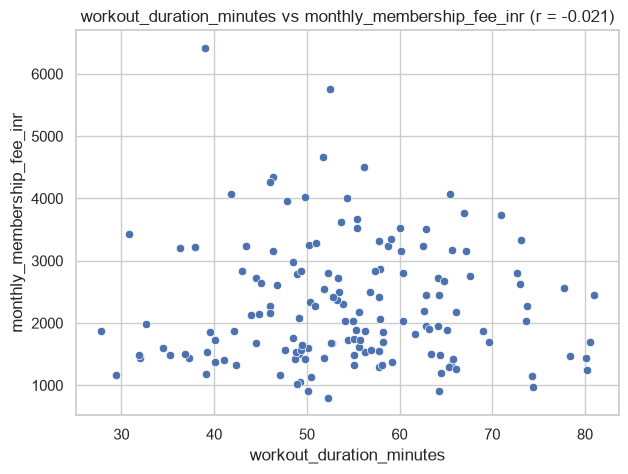

Correlation 1: 0.5207696571703803
Correlation 2: -0.02084749260999783


In [13]:
# TODO: Q12 — two scatter plots (one hypothesized relationship, one hypothesized no relationship)


pair1 = ("attendance_percentage", "weekly_visit_count")
pair2 = ("workout_duration_minutes", "monthly_membership_fee_inr")

# Pair 1
corr1 = df[pair1[0]].corr(df[pair1[1]])

plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df,
    x=pair1[0],
    y=pair1[1]
)
plt.title(f"{pair1[0]} vs {pair1[1]} (r = {corr1:.3f})")
plt.xlabel(pair1[0])
plt.ylabel(pair1[1])
plt.show()

# Pair 2
corr2 = df[pair2[0]].corr(df[pair2[1]])

plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df,
    x=pair2[0],
    y=pair2[1]
)
plt.title(f"{pair2[0]} vs {pair2[1]} (r = {corr2:.3f})")
plt.xlabel(pair2[0])
plt.ylabel(pair2[1])
plt.show()

print("Correlation 1:", corr1)
print("Correlation 2:", corr2)

## Part 6 — Synthesis

### Q13 

Build **one summary table** with a row per numeric feature and columns for: mean, median, standard
deviation, IQR, skewness, and excess kurtosis (you have already computed all of these in Q2, Q5–Q7
— this question is about assembling them, not recomputing from scratch).

Then write a short paragraph (roughly 100–150 words) that, **for each of the four features**,
recommends which central-tendency measure (mean or median) and which dispersion measure (standard
deviation or IQR) should be reported, and briefly justifies the choice using the specific evidence
in your own table (not general rules quoted from Lab 3).

In [14]:
# TODO: Q13 — assemble the comparative summary table



summary_table = pd.DataFrame({
    "Mean": df[FEATURES].mean(),
    "Median": df[FEATURES].median(),
    "Standard Deviation": df[FEATURES].std(),
    "IQR": df[FEATURES].quantile(0.75) - df[FEATURES].quantile(0.25),
    "Skewness": df[FEATURES].skew(),
    "Excess Kurtosis": df[FEATURES].kurt()
})

summary_table.index.name = "Feature"

print(summary_table)

                                Mean   Median  Standard Deviation       IQR  \
Feature                                                                       
workout_duration_minutes      54.618    54.35              11.397    14.825   
monthly_membership_fee_inr  2283.067  2030.00             984.837  1310.000   
attendance_percentage         84.210    85.10               5.874     8.600   
weekly_visit_count             3.337     2.40               1.886     3.500   

                            Skewness  Excess Kurtosis  
Feature                                                
workout_duration_minutes       0.081           -0.160  
monthly_membership_fee_inr     1.177            1.863  
attendance_percentage         -0.561           -0.324  
weekly_visit_count             0.446           -1.375  


**Your answer (recommendation paragraph):**

For workout duration, I would report the mean and standard deviation because its skewness is close to zero (0.080), suggesting an approximately symmetric distribution with no IQR outliers. For monthly membership fee, the median and IQR are more appropriate because the feature is strongly right-skewed (1.165), has heavier tails (1.761), and has two IQR outliers. For attendance percentage, I would prefer the median and IQR because it is moderately left-skewed (-0.556) and has one outlier. For weekly visit count, the median and IQR are useful because the distribution contains two distinct groups and has lighter tails; the median better represents the typical member than the mean in this situation.


---

## Bonus (optional)

Group `df` by `preferred_workout` (`df.groupby("preferred_workout")`) and compare the mean
`attendance_percentage` across the four workout categories. Is attendance noticeably different for
any one category? Give one plausible real-world explanation for what you find (or for why there's
no real difference, if that's what you observe).

In [15]:
# TODO (bonus): groupby preferred_workout, compare mean attendance_percentage across categories

attendance_by_workout = (
    df.groupby("preferred_workout")["attendance_percentage"]
      .mean()
      .sort_values(ascending=False)
)

print(attendance_by_workout)


preferred_workout
Weights     85.526
Yoga        84.029
Cardio      83.558
CrossFit    82.325
Name: attendance_percentage, dtype: float64


In [16]:
# Attendance is somewhat different across the workout categories, with Weights having the highest average attendance at about 85.53% and
# CrossFit the lowest at about 82.33%. One possible explanation is that members who prefer weight training may follow more regular routines, 
# while CrossFit members may have more variable schedules or attendance patterns.


---

### Before you submit
- [ ] Ran the notebook top to bottom with no errors (Kernel → Restart & Run All)
- [ ] Every `# TODO` cell has working code, not just comments
- [ ] Every "Your answer" cell has a written response in your own words
- [ ] Did not modify the Part 1 dataset-generation code or the random seed